# Olist Warehouse Analysis

This notebook connects to the modeled DuckDB warehouse and produces the metrics needed for the executive presentation.

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sqlalchemy import create_engine, text

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
WAREHOUSE_PATH = PROJECT_ROOT / 'data' / 'warehouse' / 'module2_project.duckdb'

engine = create_engine(f'duckdb:///{WAREHOUSE_PATH}')
sns.set_theme(style='whitegrid')

## Warehouse Inventory

In [2]:
with engine.connect() as conn:
    tables = pd.read_sql(
        text("""
        SELECT table_schema, table_name
        FROM information_schema.tables
        WHERE table_schema IN ('raw', 'warehouse')
        ORDER BY table_schema, table_name
        """),
        conn,
    )

tables

,table_schema,table_name
0,raw,raw_customers
1,raw,raw_geolocation
2,raw,raw_order_items
3,raw,raw_order_payments
4,raw,raw_order_reviews
5,raw,raw_orders
6,raw,raw_product_category_name_translation
7,raw,raw_products
8,raw,raw_sellers
9,warehouse,dim_customer


In [3]:
with engine.connect() as conn:
    row_counts = pd.read_sql(
        text("""
        SELECT 'dim_customer' AS table_name, COUNT(*) AS row_count FROM warehouse.dim_customer
        UNION ALL SELECT 'dim_product', COUNT(*) FROM warehouse.dim_product
        UNION ALL SELECT 'dim_seller', COUNT(*) FROM warehouse.dim_seller
        UNION ALL SELECT 'dim_date', COUNT(*) FROM warehouse.dim_date
        UNION ALL SELECT 'fact_sales', COUNT(*) FROM warehouse.fact_sales
        ORDER BY table_name
        """),
        conn,
    )

row_counts

,table_name,row_count
0,dim_customer,99441
1,dim_date,711
2,dim_product,32951
3,dim_seller,3095
4,fact_sales,112650


## Executive KPIs

In [4]:
with engine.connect() as conn:
    kpis = pd.read_sql(
        text("""
        SELECT
            COUNT(DISTINCT order_id) AS orders,
            COUNT(*) AS order_items,
            ROUND(SUM(total_sale_amount), 2) AS revenue,
            ROUND(SUM(total_sale_amount) / COUNT(DISTINCT order_id), 2) AS average_order_value,
            ROUND(AVG(review_score), 2) AS average_review_score,
            ROUND(AVG(delivery_days), 1) AS average_delivery_days
        FROM warehouse.fact_sales
        WHERE order_status = 'delivered'
        """),
        conn,
    )

kpis

,orders,order_items,revenue,average_order_value,average_review_score,average_delivery_days
0,96478,110197,15419773.75,159.83,4.08,12.4


## Monthly Sales Trend

In [5]:
with engine.connect() as conn:
    monthly_sales = pd.read_sql(
        text("""
        SELECT
            date_trunc('month', d.full_date)::DATE AS month_start,
            SUM(fs.total_sale_amount) AS revenue,
            COUNT(DISTINCT fs.order_id) AS orders
        FROM warehouse.fact_sales AS fs
        INNER JOIN warehouse.dim_date AS d
            ON fs.order_date_key = d.date_key
        WHERE fs.order_status = 'delivered'
        GROUP BY month_start
        ORDER BY month_start
        """),
        conn,
    )

monthly_sales.head()

,month_start,revenue,orders
0,2016-09-01,143.46,1
1,2016-10-01,46490.66,265
2,2016-12-01,19.62,1
3,2017-01-01,127482.37,750
4,2017-02-01,271239.32,1653


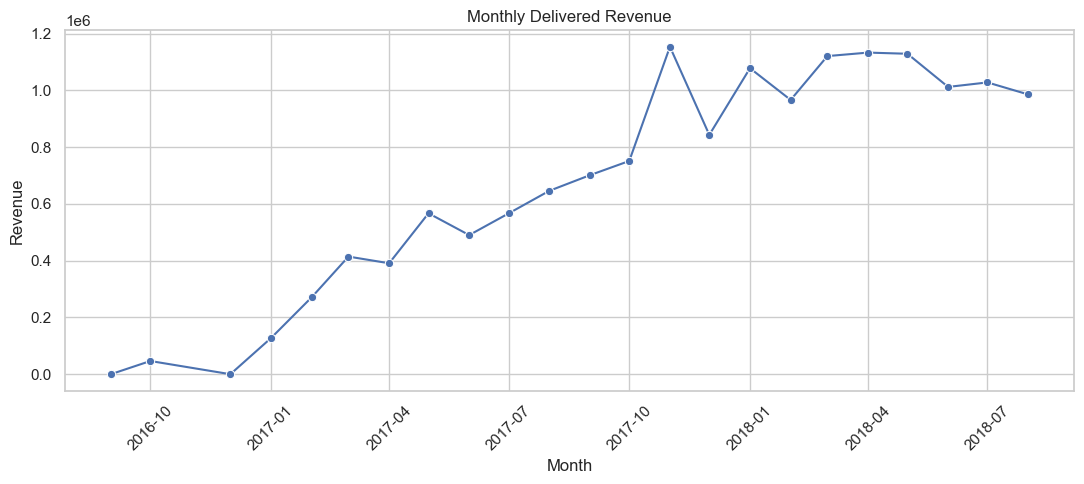

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=monthly_sales, x='month_start', y='revenue', marker='o', ax=ax)
ax.set_title('Monthly Delivered Revenue')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()

## Product Category Performance

In [7]:
with engine.connect() as conn:
    category_sales = pd.read_sql(
        text("""
        SELECT
            COALESCE(dp.product_category_name_english, 'unknown') AS category,
            ROUND(SUM(fs.total_sale_amount), 2) AS revenue,
            COUNT(DISTINCT fs.order_id) AS orders,
            ROUND(AVG(fs.review_score), 2) AS average_review_score
        FROM warehouse.fact_sales AS fs
        LEFT JOIN warehouse.dim_product AS dp
            ON fs.product_key = dp.product_key
        WHERE fs.order_status = 'delivered'
        GROUP BY category
        ORDER BY revenue DESC
        LIMIT 10
        """),
        conn,
    )

category_sales

,category,revenue,orders,average_review_score
0,health_beauty,1412089.53,8647,4.19
1,watches_gifts,1264333.12,5495,4.07
2,bed_bath_table,1225209.26,9272,3.92
3,sports_leisure,1118256.91,7530,4.17
4,computers_accessories,1032723.77,6530,3.99
5,furniture_decor,880329.92,6307,3.95
6,housewares,758392.25,5743,4.11
7,cool_stuff,691680.89,3559,4.19
8,auto,669454.75,3810,4.12
9,garden_tools,567145.68,3448,4.08


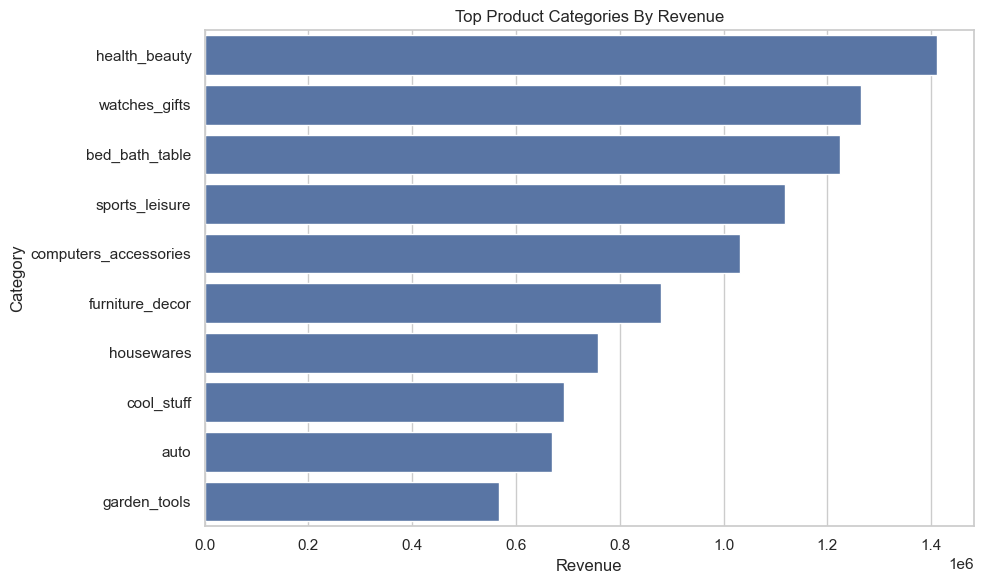

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=category_sales, y='category', x='revenue', ax=ax)
ax.set_title('Top Product Categories By Revenue')
ax.set_xlabel('Revenue')
ax.set_ylabel('Category')
plt.tight_layout()

## Customer Segmentation

In [9]:
with engine.connect() as conn:
    customer_segments = pd.read_sql(
        text("""
        WITH customer_orders AS (
            SELECT
                dc.customer_unique_id,
                dc.customer_state,
                COUNT(DISTINCT fs.order_id) AS orders,
                SUM(fs.total_sale_amount) AS revenue
            FROM warehouse.fact_sales AS fs
            INNER JOIN warehouse.dim_customer AS dc
                ON fs.customer_key = dc.customer_key
            WHERE fs.order_status = 'delivered'
            GROUP BY dc.customer_unique_id, dc.customer_state
        )
        SELECT
            CASE
                WHEN orders >= 3 THEN 'repeat 3+'
                WHEN orders = 2 THEN 'repeat 2'
                ELSE 'one-time'
            END AS segment,
            COUNT(*) AS customers,
            ROUND(SUM(revenue), 2) AS revenue,
            ROUND(AVG(revenue), 2) AS average_customer_value
        FROM customer_orders
        GROUP BY segment
        ORDER BY revenue DESC
        """),
        conn,
    )

customer_segments

,segment,customers,revenue,average_customer_value
0,one-time,90629,14565801.31,160.72
1,repeat 2,2542,740576.10,291.34
2,repeat 3+,225,113396.34,503.98


## Recommendation Notes

- Identify the top revenue categories and decide whether they should receive more marketing support.
- Compare high-revenue categories with review scores to find quality or fulfillment risks.
- Use customer geography to prioritize regional campaigns and seller coverage.
- Use delivery variance to identify fulfillment improvements that may lift customer satisfaction.